# GHZ States

In [15]:
from numpy import pi

In [16]:
# Importing standard Qiskit libraries

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_distribution
from qiskit import transpile
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import *
from qiskit_aer import AerSimulator

In [17]:
# Descomente la siguiente linea si desea ver las imágenes más grandes.
%config InlineBackend.figure_format = 'svg' # Makes the images look nice

In [18]:
backend_simulator = AerSimulator()
backend_device = FakeVigoV2()

# Circuit for a GHZ State:

In [19]:
nqubits = 3
circuit = QuantumCircuit(nqubits, nqubits)
circuit.h(0)
circuit.cx(0,1)
circuit.cx(1,2)
circuit.measure([0,1,2], [0,1,2])

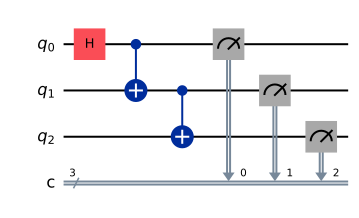

In [20]:
circuit.draw(output='mpl')

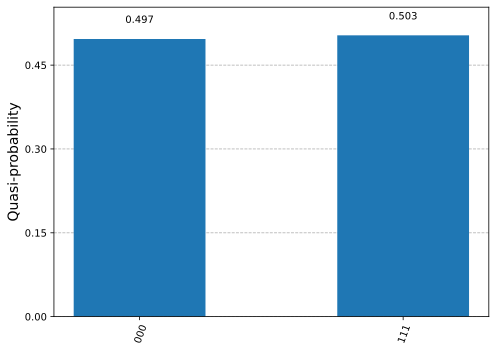

In [21]:
shots = 8192
sim_result = backend_simulator.run((circuit), shots=shots).result()
sim_counts = sim_result.get_counts(circuit)

plot_distribution(sim_counts)

In [22]:
transpiled_circuit = transpile(circuit, backend_device)

In [23]:
sampler2run = Sampler(mode=backend_device)

In [24]:
# Define the number of shots for the execution. 
shotno=1024

# Run the circuit on a real quantum computer. NB! This may take a while.
job = sampler2run.run([transpiled_circuit], shots= shotno)

# ID del Job para rastrear la ejecución del circuito en tiempo real.
print(f">>> Job ID: {job.job_id()}")

# Consulta del estado de la ejecución del circuito cuántico
print(f">>> Job Status: {job.status()}")

>>> Job ID: cc392771-26a7-481c-9ac6-f080345b6d64
>>> Job Status: JobStatus.RUNNING


In [25]:
device_result = job.result()

# Get results for the first (and only) PUB
pub_result = device_result[0]

# Get count measurement results
device_counts = pub_result.data.c.get_counts()

print(
    f"Counts for the 'meas' output register: {device_counts}"
)

Counts for the 'meas' output register: {'111': 445, '000': 524, '101': 17, '001': 4, '100': 5, '011': 16, '010': 5, '110': 8}


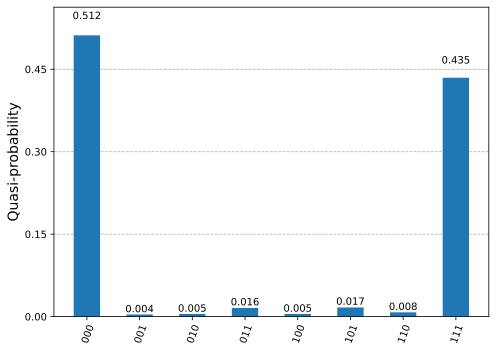

In [26]:
# Probabilidades de medición de cada salida, dada la ejecución real realizada.
plot_distribution(device_counts)

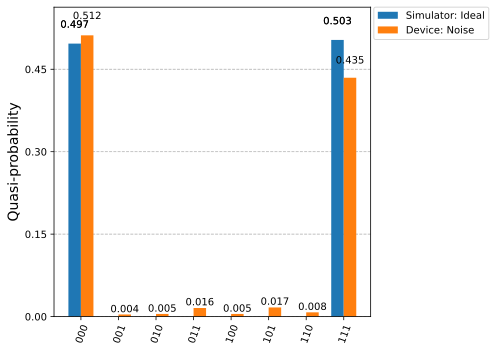

In [27]:
plot_distribution([sim_counts, device_counts], 
               legend=['Simulator: Ideal', 'Device: Noise'])

In [28]:
from qiskit import __version__ as qiskit_version
from qiskit_ibm_runtime import __version__ as runtime_version
from qiskit_aer import __version__ as aer_version
from platform import python_version

print('Qiskit Version:', qiskit_version)
print('IBM RunTime Version:', runtime_version)
print('Qiskit_Aer Version:', aer_version)
print('Python Version:', python_version())
print('2026 ©')

Qiskit Version: 2.0.0
IBM RunTime Version: 0.38.0
Qiskit_Aer Version: 0.17.0
Python Version: 3.13.2
2026 ©
